Dataset Shape: (9659, 14)
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159   19M      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967   14M     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510  8.7M   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644   25M  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967  2.8M     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Ar

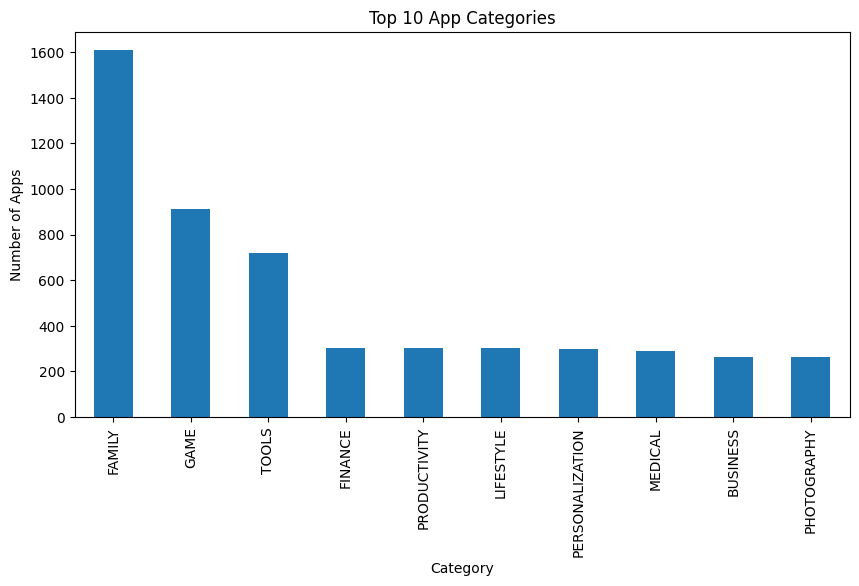

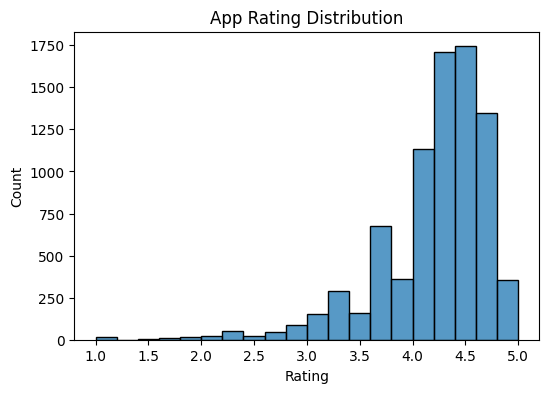

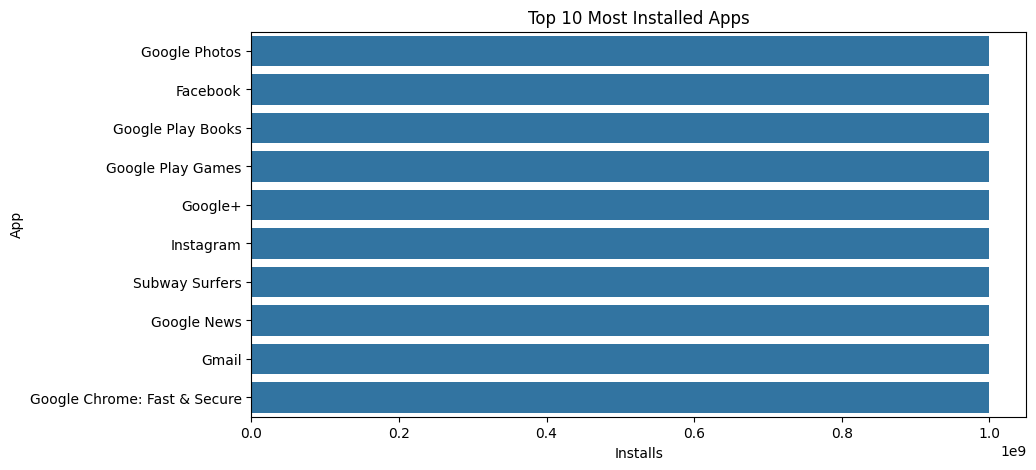

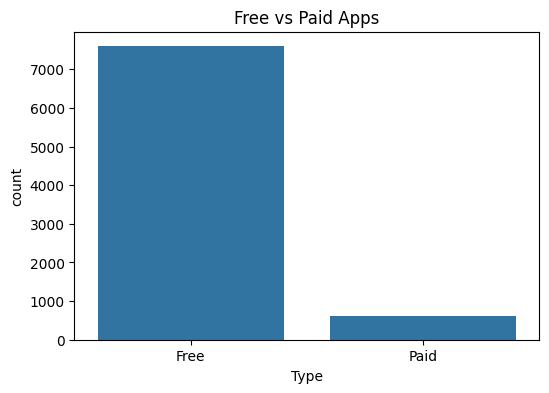

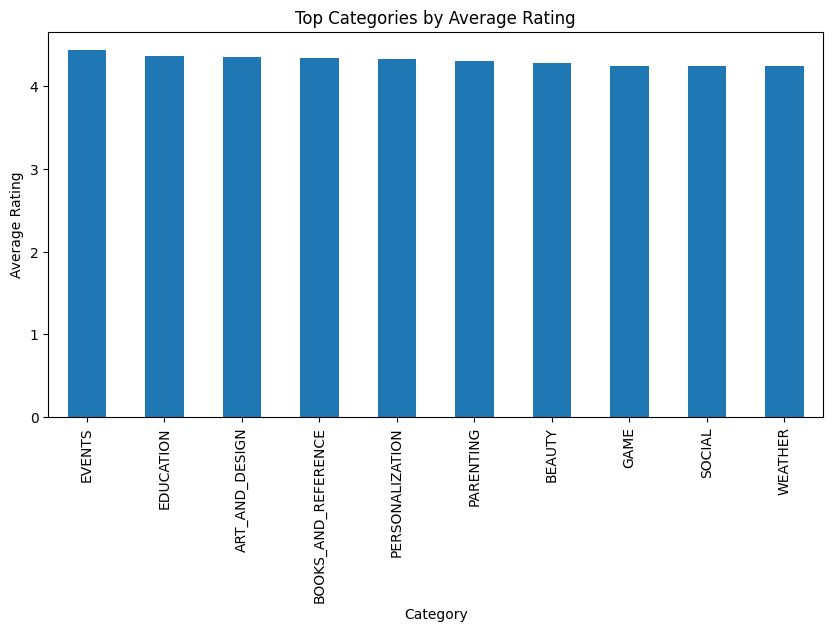

In [9]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
data = pd.read_csv("apps.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# Step 3: Data Cleaning
data.drop_duplicates(inplace=True)

# Convert Rating to numeric
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')

# Remove missing values
data.dropna(subset=['Rating'], inplace=True)

# Step 4: Top Categories
plt.figure(figsize=(10,5))
data['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.show()

# Step 5: Rating Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['Rating'], bins=20)
plt.title("App Rating Distribution")
plt.show()

# Step 6: Installs Analysis
data['Installs'] = data['Installs'].str.replace('+','')
data['Installs'] = data['Installs'].str.replace(',','')
data['Installs'] = pd.to_numeric(data['Installs'], errors='coerce')

top_apps = data.sort_values(by='Installs', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_apps['Installs'], y=top_apps['App'])
plt.title("Top 10 Most Installed Apps")
plt.show()

# Step 7: Paid vs Free Apps
plt.figure(figsize=(6,4))
sns.countplot(x=data['Type'])
plt.title("Free vs Paid Apps")
plt.show()

# Step 8: Average Rating per Category
avg_rating = data.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_rating.plot(kind='bar')
plt.title("Top Categories by Average Rating")
plt.ylabel("Average Rating")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
Columns: Index(['clean_text', 'category'], dtype='object')
Dataset Shape: (162969, 2)


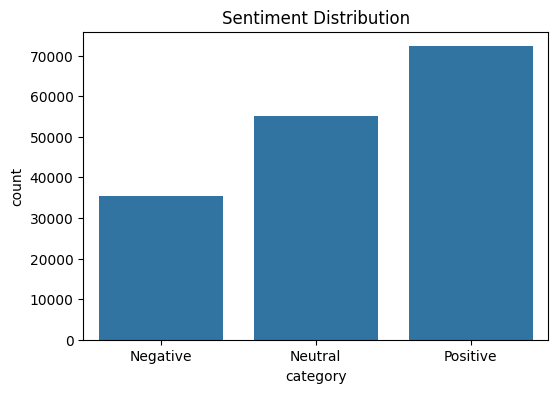

Accuracy: 0.7266674848131558

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.43      0.58      7152
     Neutral       0.84      0.66      0.74     11067
    Positive       0.65      0.93      0.77     14375

    accuracy                           0.73     32594
   macro avg       0.79      0.67      0.69     32594
weighted avg       0.77      0.73      0.72     32594



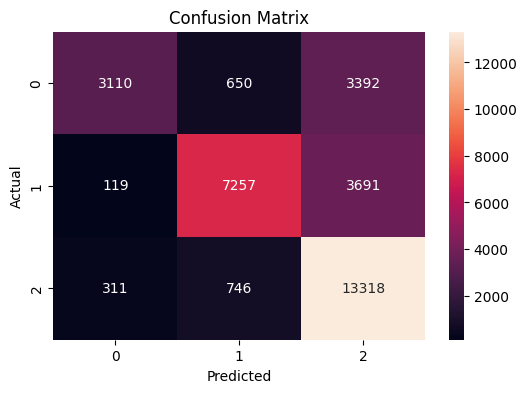

Enter a tweet: This app is really useful and works perfectly
Predicted Sentiment: Positive


In [11]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

# Step 2: Load Dataset
data = pd.read_csv("Twitter_Data.csv")

# Display dataset
print(data.head())
print("Columns:", data.columns)

# Keep required columns
data = data[['clean_text', 'category']]

# Remove missing values
data.dropna(inplace=True)

# Convert category numbers to labels
data['category'] = data['category'].replace({
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
})

print("Dataset Shape:", data.shape)

# Step 3: Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=data['category'])
plt.title("Sentiment Distribution")
plt.show()

# Step 4: Text Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

data['processed_text'] = data['clean_text'].apply(preprocess)

# Step 5: Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['processed_text'])
y = data['category']

# Step 6: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 8: Prediction
y_pred = model.predict(X_test)

# Step 9: Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 11: Test Custom Input
text = input("Enter a tweet: ")

clean = preprocess(text)
vector = vectorizer.transform([clean])

prediction = model.predict(vector)

print("Predicted Sentiment:", prediction[0])